Libraries loaded successfully
X_train shape : (2586, 21)
X_test shape  : (384, 21)
Crisis cases  : 60
Dtypes after cast:
sex                       int32
education                 int32
marital_status            int32
region                    int32
employment_status         int32
employment_type           int32
h19_pers_income1        float64
h19_pers_income2        float64
h19_pers_income4        float64
h19_cin                 float64
h19_din                 float64
debt_financial          float64
debt_private            float64
debt_card               float64
debt_lease              float64
debt_credit             float64
debt_other              float64
housing_debt_balance    float64
housing_tenure            int32
age                     float64
total_debt              float64
debt_crisis               int32
dtype: object
DiCE Data object created
Continuous features : ['sex', 'education', 'marital_status', 'region', 'employment_status', 'employment_type', 'h19_pers_income1', 'h19_

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.57it/s]


Case  1 | orig=0.999 | CF1: 0.028(1chg) | CF2: 0.033(2chg) | CF3: 0.028(1chg)


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.31it/s]


Case  2 | orig=0.062 | CF1: 0.524(1chg) | CF2: 0.954(2chg) | CF3: 0.993(2chg)


...

Case  8 | orig=0.973 | CF1: 0.003(1chg) | CF2: 0.001(2chg) | CF3: 0.492(1chg)



100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.38it/s]


Case  9 | orig=0.834 | CF1: 0.100(2chg) | CF2: 0.197(2chg) | CF3: 0.133(2chg)


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.74it/s]


Case 10 | orig=0.084 | CF1: 0.578(2chg) | CF2: 0.531(2chg) | CF3: 0.944(2chg)

Successful : 10 / 10
=== DiCE Counterfactual Summary ===
 case_id  prob_original  cf_id  prob_cf  pred_cf  n_changes                                    changed_features
       5         0.9992      1   0.0275        0          1                                    h19_pers_income2
       5         0.9992      2   0.0327        0          2                       h19_pers_income2, debt_credit
       5         0.9992      3   0.0275        0          1                                    h19_pers_income2
       8         0.0615      1   0.5242        1          1                                             h19_cin
       8         0.0615      2   0.9543        1          2                        h19_pers_income2, total_debt
       8         0.0615      3   0.9931        1          2                         education, h19_pers_income2
      10         0.9879      1   0.0116        0          1                     

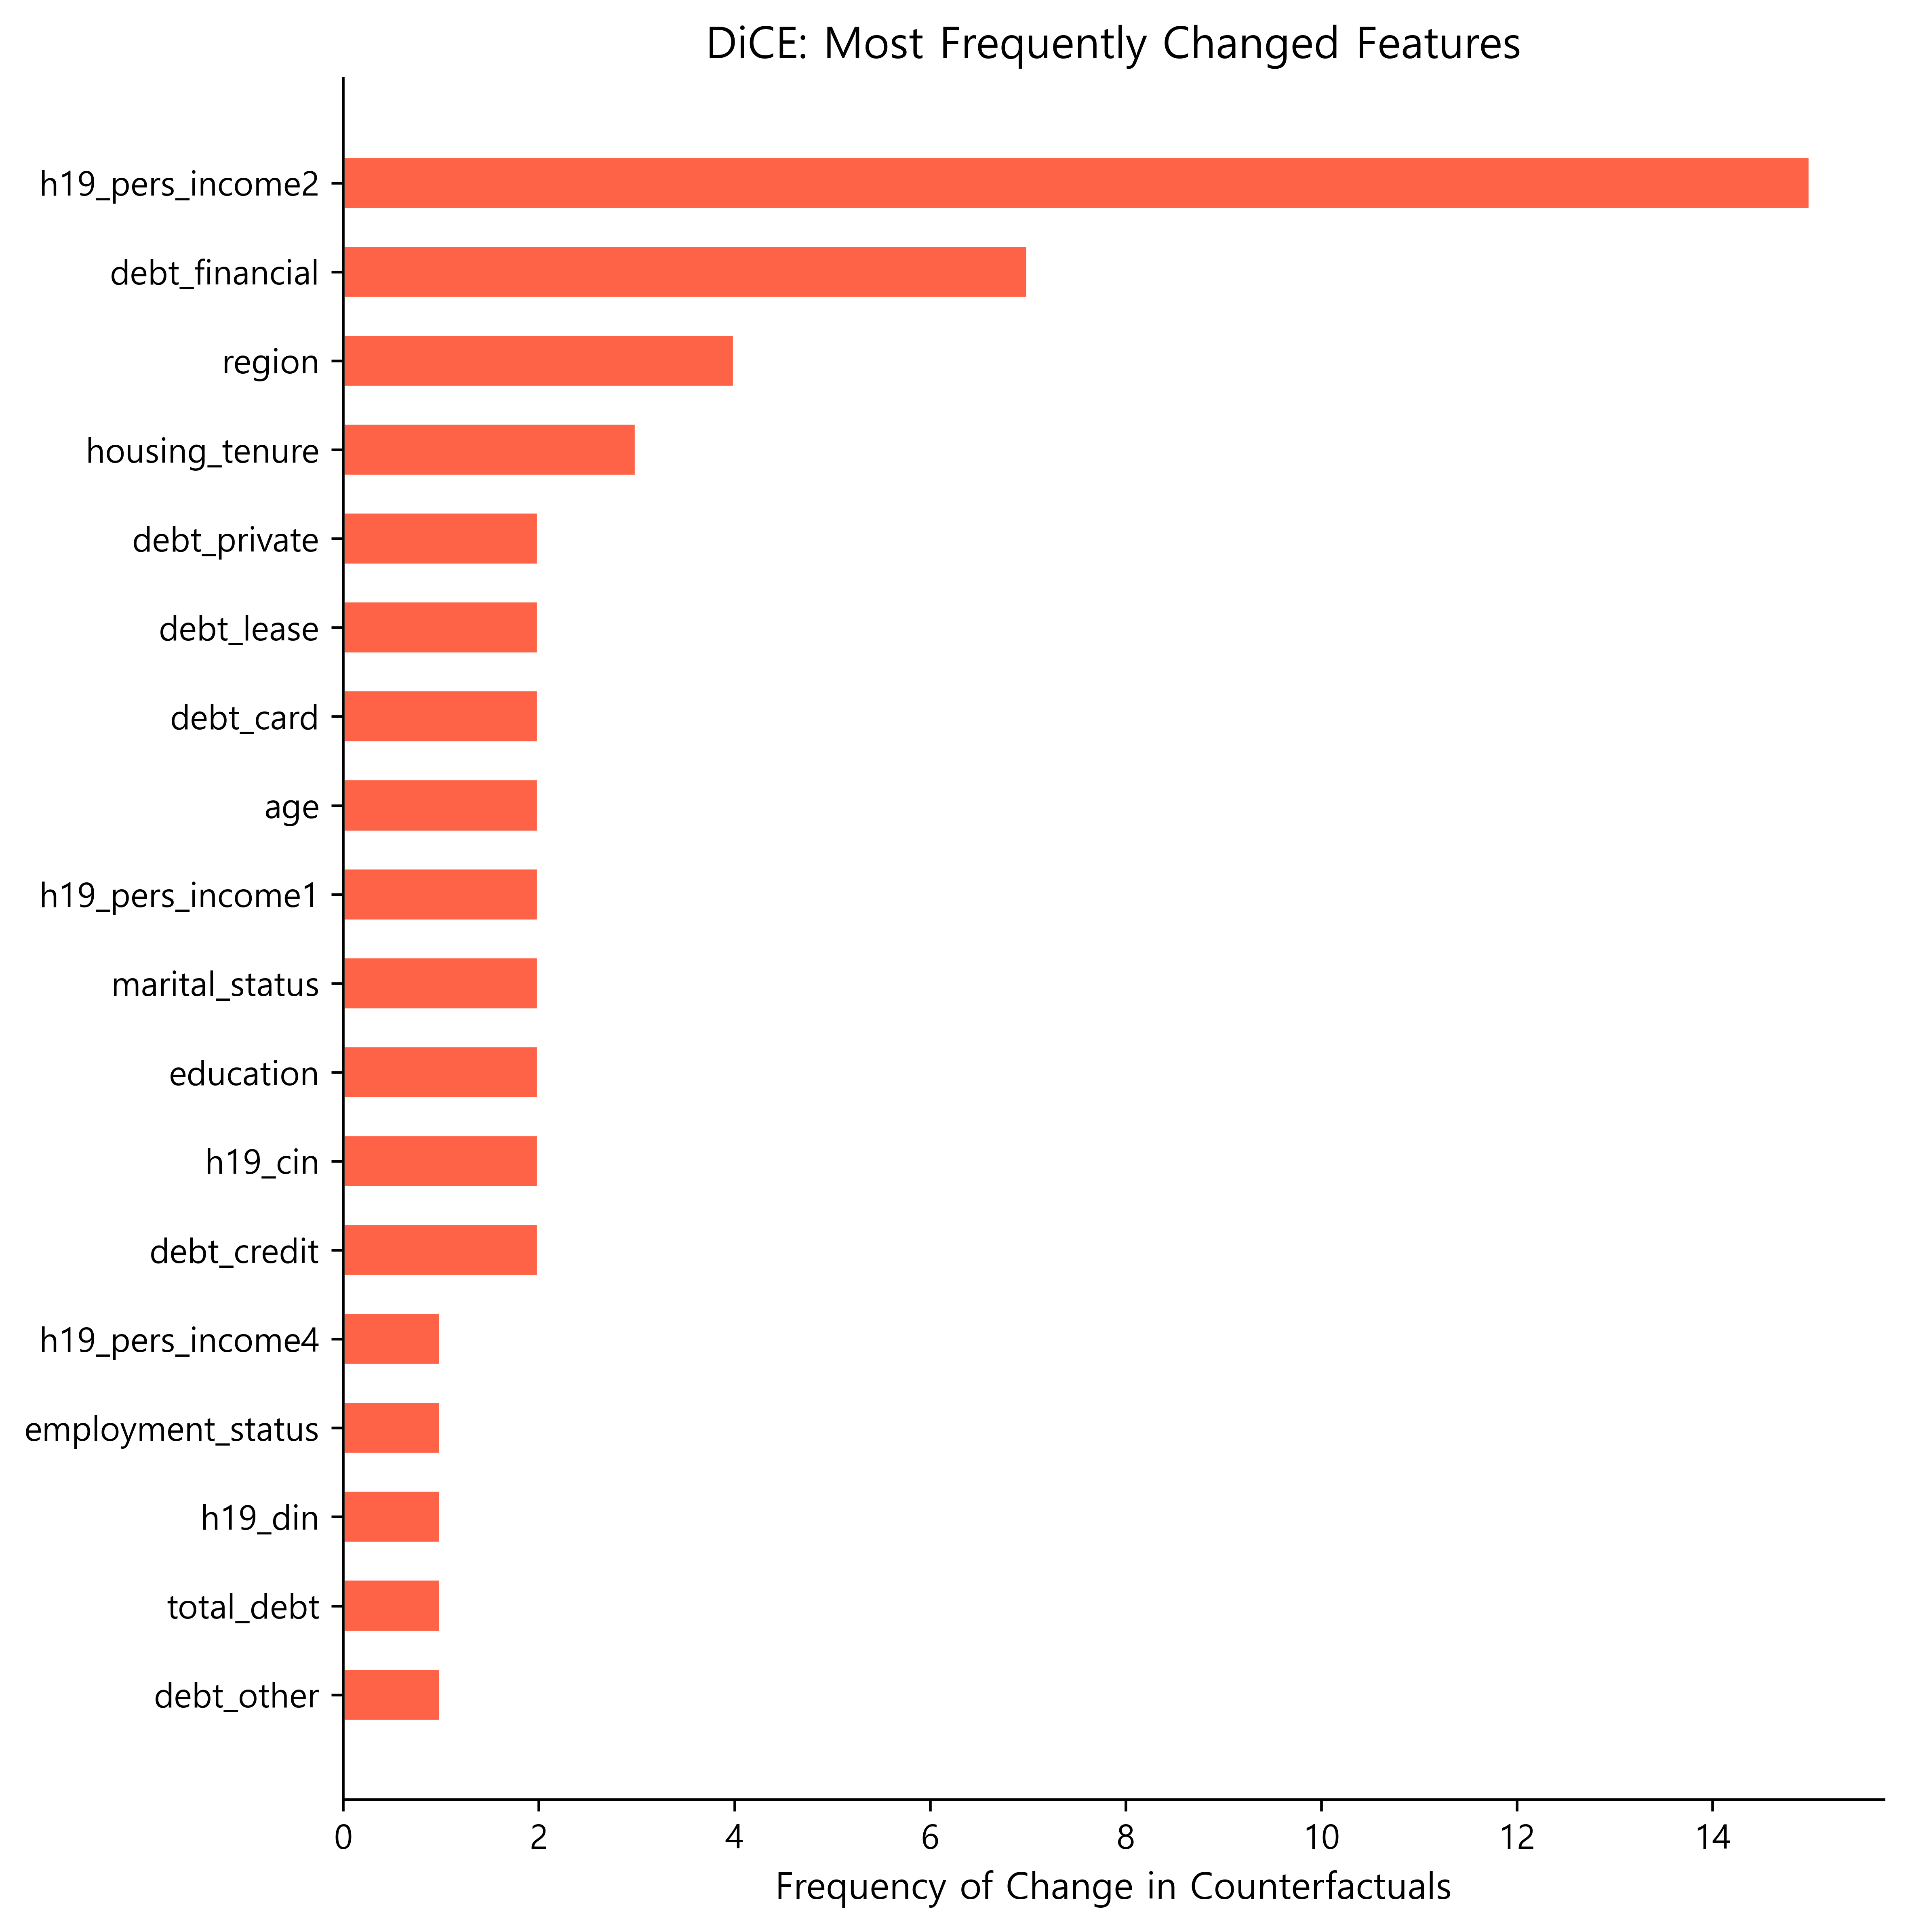

Saved -> outputs/18_dice_change_freq.png


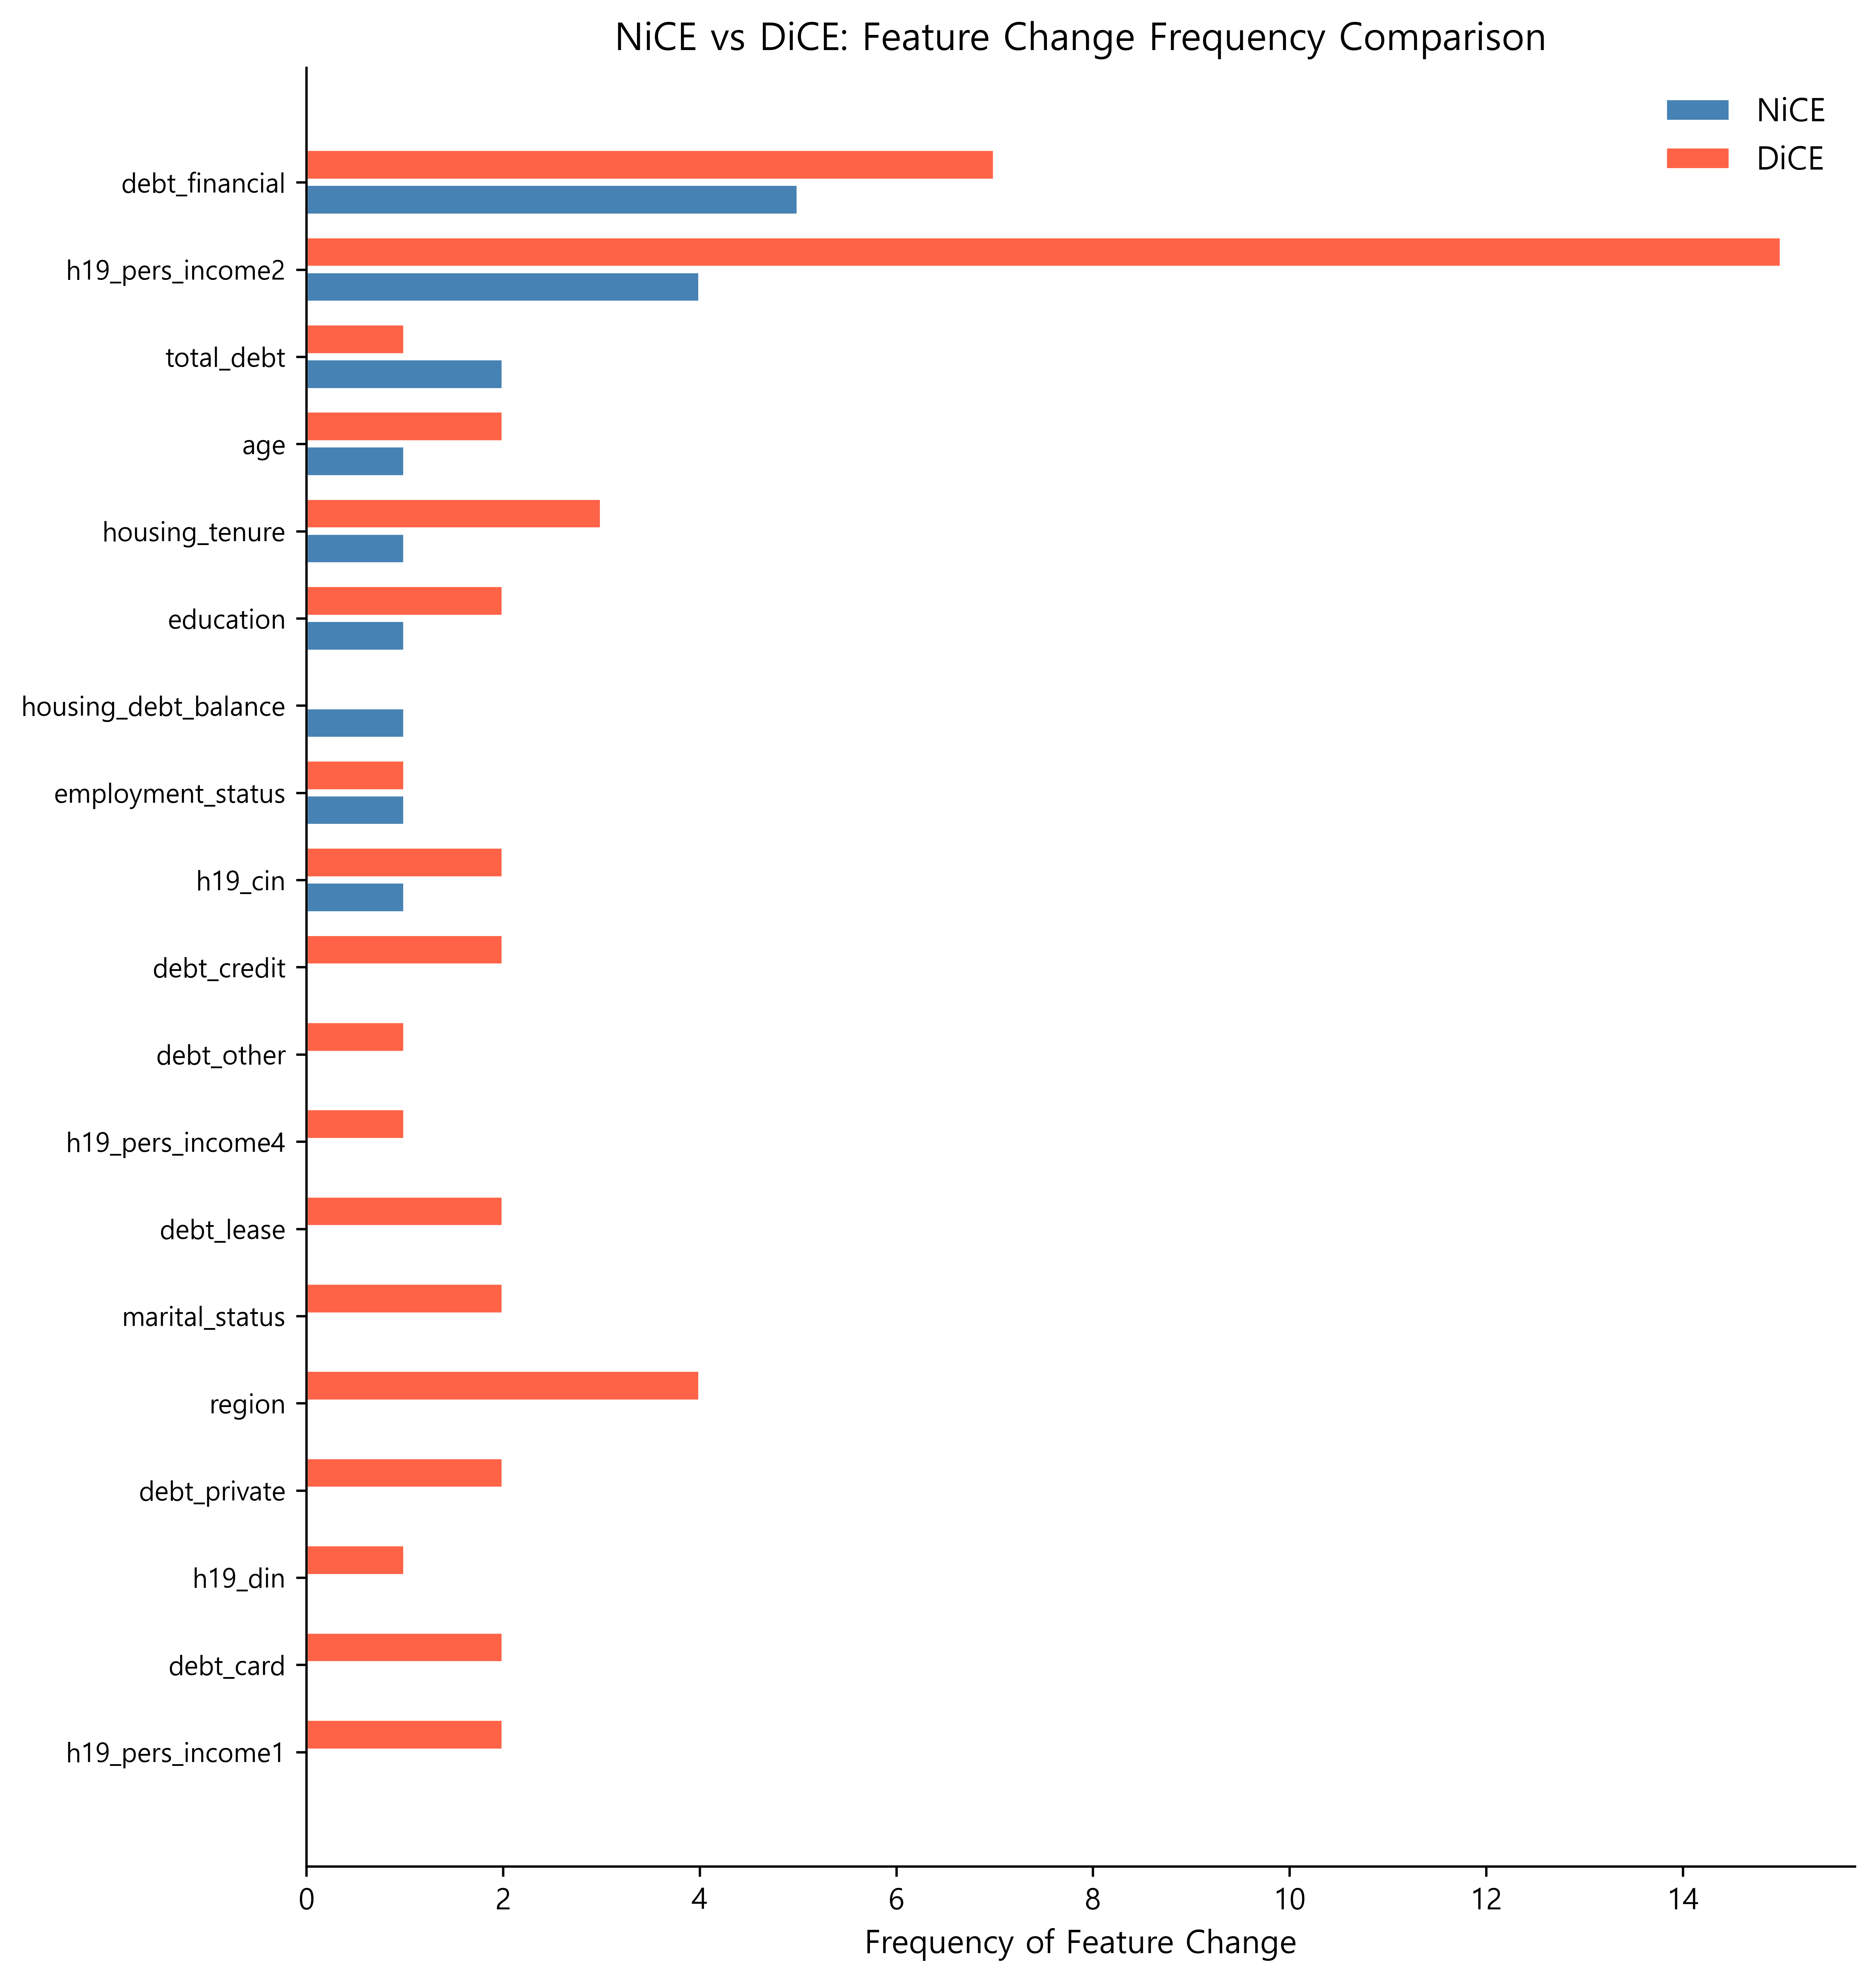

Saved -> outputs/19_nice_vs_dice_comparison.png


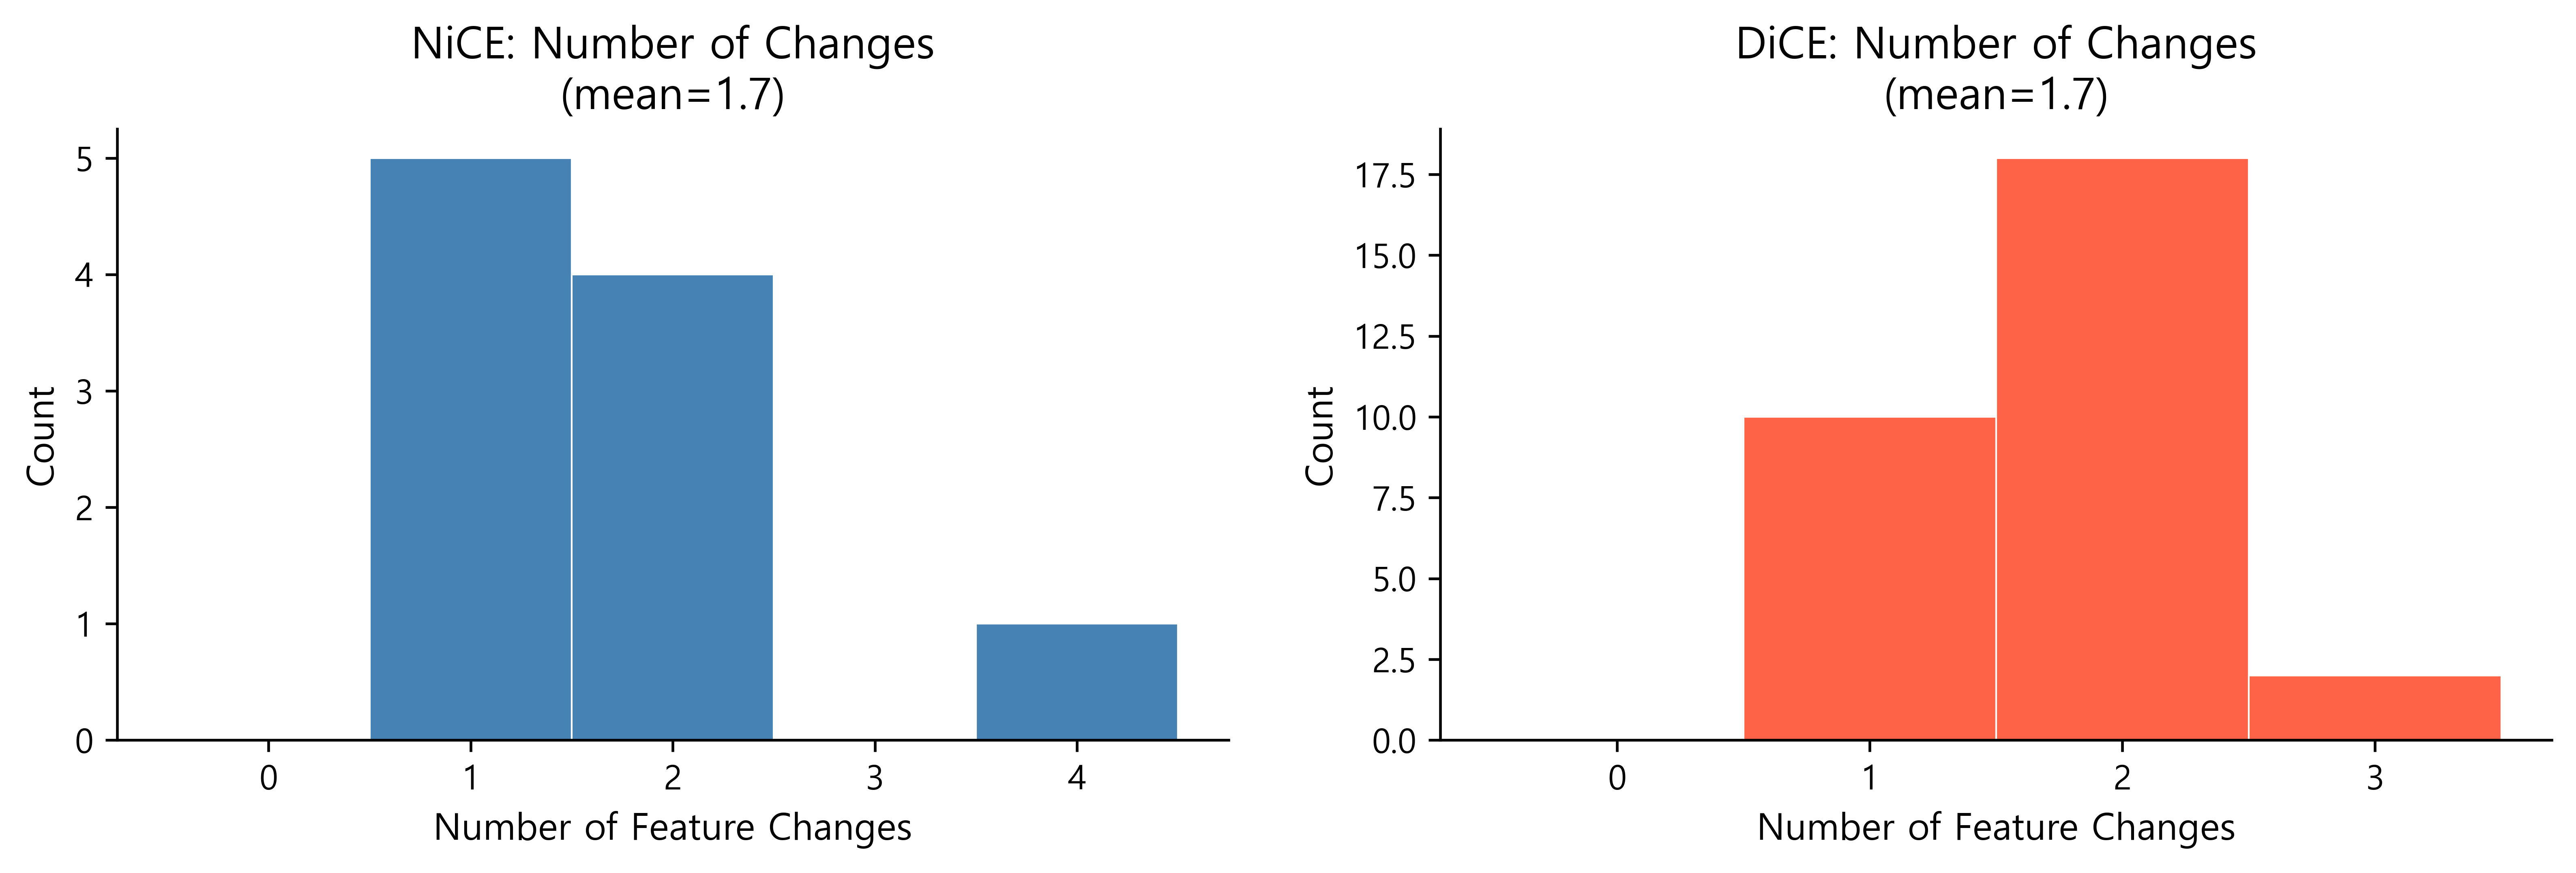

Saved -> outputs/20_sparsity_comparison.png
Saved -> outputs/dice_cf_full.csv  |  Shape: (40, 24)


In [5]:
# ─────────────────────────────────────────────
# Cell 1 | Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
import joblib
import dice_ml
from dice_ml import Dice

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['lines.linewidth'] = 1.5
matplotlib.rcParams['axes.linewidth'] = 0.8

SAVE_KW = dict(dpi=600, bbox_inches='tight', format='png')

print("Libraries loaded successfully")


# ─────────────────────────────────────────────
# Cell 2 | Load model & data
# ─────────────────────────────────────────────
lgbm    = joblib.load('../outputs/model_lgbm.pkl')
X_train = pd.read_csv('../data/X_train_sm.csv')
y_train = pd.read_csv('../data/y_train_sm.csv').squeeze()
X_test  = pd.read_csv('../data/X_test.csv')
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

X_test_r = X_test.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)

crisis_idx = y_test_r[y_test_r == 1].index.tolist()

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test_r.shape}")
print(f"Crisis cases  : {len(crisis_idx)}")


# ─────────────────────────────────────────────
# Cell 3 | Prepare DiCE data object
# ─────────────────────────────────────────────
CAT_FEATURES = ['sex', 'education', 'marital_status', 'region',
                'employment_status', 'employment_type', 'housing_tenure']

# DiCE requires all columns to be int/float — cast categorical to int
train_df = X_train.copy()
for col in CAT_FEATURES:
    if col in train_df.columns:
        train_df[col] = pd.to_numeric(train_df[col], errors='coerce').astype(int)
train_df['debt_crisis'] = y_train.values.astype(int)

# Cast ALL columns in X_test_r to numeric
X_test_r = X_test_r.apply(pd.to_numeric, errors='coerce')
for col in CAT_FEATURES:
    if col in X_test_r.columns:
        X_test_r[col] = X_test_r[col].fillna(0).astype(int)

# Also cast X_train for consistency
X_train = X_train.apply(pd.to_numeric, errors='coerce')
for col in CAT_FEATURES:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna(0).astype(int)

# Treat ALL features as continuous to avoid DiCE internal object cast bug
# (categorical are already encoded as integers so this is numerically valid)
d = dice_ml.Data(
    dataframe=train_df,
    continuous_features=[c for c in X_train.columns],  # all as continuous
    outcome_name='debt_crisis'
)

print("Dtypes after cast:")
print(train_df.dtypes)

print("DiCE Data object created")
print(f"Continuous features : {d.continuous_feature_names}")
print(f"Categorical features: {CAT_FEATURES}")


# ─────────────────────────────────────────────
# Cell 4 | Define DiCE model object
# ─────────────────────────────────────────────
# Wrap LightGBM with DiCE model interface
m = dice_ml.Model(model=lgbm, backend='sklearn')

# Initialize DiCE explainer
# method options: 'random', 'genetic', 'kdtree'
exp = Dice(d, m, method='random')

print("DiCE explainer initialized")
print(f"Method : random")


# ─────────────────────────────────────────────
# Cell 5 | Generate counterfactuals
# ─────────────────────────────────────────────
N_CF        = 3    # number of counterfactuals per instance
N_CASES     = min(10, len(crisis_idx))
sample_idx  = crisis_idx[:N_CASES]

results = []

for i in range(N_CASES):
    idx      = sample_idx[i]
    instance = X_test_r.iloc[[idx]].copy()
    # Ensure all dtypes are numeric before passing to DiCE
    instance = instance.apply(pd.to_numeric, errors='coerce').fillna(0)

    try:
        dice_exp = exp.generate_counterfactuals(
            instance,
            total_CFs=N_CF,
            desired_class='opposite',
            verbose=False,
        )

        cf_df = dice_exp.cf_examples_list[0].final_cfs_df
        if cf_df is None or len(cf_df) == 0:
            print(f"Case {i+1:>2} | No CFs found")
            continue

        # Remove target column from cf_df if present
        if 'debt_crisis' in cf_df.columns:
            cf_df = cf_df.drop(columns=['debt_crisis'])

        prob_orig = lgbm.predict_proba(instance.values)[0][1]

        cf_records = []
        for j in range(len(cf_df)):
            cf_row    = cf_df.iloc[[j]]
            prob_cf   = lgbm.predict_proba(cf_row.values)[0][1]
            pred_cf   = int(lgbm.predict(cf_row.values)[0])

            diff      = (instance.values != cf_row.values)[0]
            changed   = [X_train.columns[k] for k in range(len(diff)) if diff[k]]
            n_changes = int(diff.sum())

            cf_records.append({
                'cf_id'          : j + 1,
                'prob_cf'        : round(float(prob_cf), 4),
                'pred_cf'        : pred_cf,
                'n_changes'      : n_changes,
                'changed_features': changed,
                'cf_row'         : cf_row,
            })

        results.append({
            'case_id'      : idx,
            'prob_original': round(float(prob_orig), 4),
            'cfs'          : cf_records,
            'original'     : instance,
        })

        cf_summary_str = ' | '.join(
            [f"CF{r['cf_id']}: {r['prob_cf']:.3f}({r['n_changes']}chg)"
             for r in cf_records]
        )
        print(f"Case {i+1:>2} | orig={prob_orig:.3f} | {cf_summary_str}")

    except Exception as e:
        print(f"Case {i+1:>2} | Failed: {e}")

print(f"\nSuccessful : {len(results)} / {N_CASES}")


# ─────────────────────────────────────────────
# Cell 6 | Flatten results into summary table
# ─────────────────────────────────────────────
rows = []
for r in results:
    for cf in r['cfs']:
        rows.append({
            'case_id'         : r['case_id'],
            'prob_original'   : r['prob_original'],
            'cf_id'           : cf['cf_id'],
            'prob_cf'         : cf['prob_cf'],
            'pred_cf'         : cf['pred_cf'],
            'n_changes'       : cf['n_changes'],
            'changed_features': ', '.join(cf['changed_features']),
        })

cf_summary = pd.DataFrame(rows)
print("=== DiCE Counterfactual Summary ===")
print(cf_summary.to_string(index=False))

cf_summary.to_csv('../outputs/dice_cf_summary.csv', index=False, encoding='utf-8-sig')
print("\nSaved -> outputs/dice_cf_summary.csv")


# ─────────────────────────────────────────────
# Cell 7 | Feature change frequency
# ─────────────────────────────────────────────
from collections import Counter

all_changed = []
for r in results:
    for cf in r['cfs']:
        all_changed.extend(cf['changed_features'])

change_freq = Counter(all_changed)
change_df = pd.DataFrame(change_freq.items(),
                         columns=['feature', 'count'])\
              .sort_values('count', ascending=True)

print("=== Most frequently changed features (DiCE) ===")
print(change_df.sort_values('count', ascending=False).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, max(3, len(change_df)*0.45)))
ax.barh(change_df['feature'], change_df['count'],
        color='tomato', edgecolor='white', height=0.6)
ax.set_xlabel('Frequency of Change in Counterfactuals')
ax.set_title('DiCE: Most Frequently Changed Features')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/18_dice_change_freq.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/18_dice_change_freq.png")


# ─────────────────────────────────────────────
# Cell 8 | NiCE vs DiCE comparison — change freq
# ─────────────────────────────────────────────
# Load NiCE results for comparison
nice_summary = pd.read_csv('../outputs/nice_cf_summary.csv')

nice_changed = []
for feats in nice_summary['changed_features'].dropna():
    nice_changed.extend([f.strip() for f in feats.split(',')])

nice_freq = Counter(nice_changed)
dice_freq = change_freq

all_features = list(set(list(nice_freq.keys()) + list(dice_freq.keys())))
nice_counts  = [nice_freq.get(f, 0) for f in all_features]
dice_counts  = [dice_freq.get(f, 0) for f in all_features]

# Sort by NiCE count
order = np.argsort(nice_counts)
all_features = [all_features[i] for i in order]
nice_counts  = [nice_counts[i]  for i in order]
dice_counts  = [dice_counts[i]  for i in order]

y_pos = np.arange(len(all_features))

fig, ax = plt.subplots(figsize=(9, max(4, len(all_features)*0.5)))
ax.barh(y_pos - 0.2, nice_counts, height=0.35,
        color='steelblue', label='NiCE', edgecolor='white')
ax.barh(y_pos + 0.2, dice_counts, height=0.35,
        color='tomato', label='DiCE', edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(all_features, fontsize=9)
ax.set_xlabel('Frequency of Feature Change')
ax.set_title('NiCE vs DiCE: Feature Change Frequency Comparison')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/19_nice_vs_dice_comparison.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/19_nice_vs_dice_comparison.png")


# ─────────────────────────────────────────────
# Cell 9 | Sparsity comparison (n_changes)
# ─────────────────────────────────────────────
nice_n = nice_summary['n_changes'].dropna().tolist()
dice_n = cf_summary['n_changes'].dropna().tolist() if 'n_changes' in cf_summary.columns else []

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, data, title, color in zip(
    axes,
    [nice_n, dice_n],
    ['NiCE: Number of Changes', 'DiCE: Number of Changes'],
    ['steelblue', 'tomato']
):
    if len(data) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        continue
    ax.hist(data, bins=range(0, int(max(data))+2),
            color=color, edgecolor='white', linewidth=0.5, align='left')
    ax.set_xlabel('Number of Feature Changes')
    ax.set_ylabel('Count')
    ax.set_title(f'{title}\n(mean={np.mean(data):.1f})')
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/20_sparsity_comparison.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/20_sparsity_comparison.png")


# ─────────────────────────────────────────────
# Cell 10 | Save full DiCE records
# ─────────────────────────────────────────────
if len(results) == 0:
    print("No results to save.")
else:
    cf_records = []
    for r in results:
        orig_row = r['original'].copy()
        orig_row['type']    = 'original'
        orig_row['case_id'] = r['case_id']
        orig_row['cf_id']   = 0
        cf_records.append(orig_row)

        for cf in r['cfs']:
            cf_row = cf['cf_row'].copy()
            cf_row['type']    = 'counterfactual'
            cf_row['case_id'] = r['case_id']
            cf_row['cf_id']   = cf['cf_id']
            cf_records.append(cf_row)

    cf_full = pd.concat(cf_records, ignore_index=True)
    cf_full.to_csv('../outputs/dice_cf_full.csv', index=False, encoding='utf-8-sig')
    print(f"Saved -> outputs/dice_cf_full.csv  |  Shape: {cf_full.shape}")